<a href="https://colab.research.google.com/github/somar9/Neutrino-Oscillation-Project/blob/ND-simulation---Gaussian/2_Flavour_oscillation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import curve_fit

# Conversion and Matter Constants
CONV_KM_TO_INV_EV = 5.067731e9          # km → 1/eV conversion factor
VCC_EARTH_CRUST = 7.6e-14               # Earth crust matter potential (eV)

# Three-flavor (3ν) standard parameters (in radians)
theta12 = np.radians(33.82)
theta13 = np.radians(8.61)
theta23 = np.radians(48.3)
delta13 = 0                           # CP phase (can change to np.pi/2 for CP variation)
D21 = 7.39e-5                         # solar mass-sq. diff (eV^2)
D31 = 2.525e-3                        # atmospheric mass-sq. diff (eV^2)

# Additional Four-flavor (3+1) parameters
theta14 = np.radians(10.0)
theta24 = np.radians(5.0)
theta34 = np.radians(2.0)
delta14 = 0                           # additional CP phase for sterile
D41 = 1.0                             # sterile mass-sq. diff (eV^2)

# Energy and Baseline Definitions
energies_GeV = np.linspace(0.5, 5, 50)       # Energy array in GeV
energies_eV = energies_GeV * 1e9             # Energy array in eV

Length_near = 1    # km
Length_far  = 810  # km


In [2]:
# 3-Flavor (3ν) Model Functions
def mixing_matrix_3nu(theta12, theta13, theta23, delta):
    c12, c13, c23 = np.cos([theta12, theta13, theta23])
    s12, s13, s23 = np.sin([theta12, theta13, theta23])
    U = np.array([
        [c12 * c13, s12 * c13, s13 * np.exp(-1j * delta)],
        [-s12 * c23 - c12 * s13 * s23 * np.exp(1j * delta),
         c12 * c23 - s12 * s13 * s23 * np.exp(1j * delta),
         c13 * s23],
        [s12 * s23 - c12 * s13 * c23 * np.exp(1j * delta),
         -c12 * s23 - s12 * s13 * c23 * np.exp(1j * delta),
         c13 * c23]
    ])
    return U

def hamiltonian_3nu_vacuum(E):
    m2 = np.diag([0, D21, D31])
    U = mixing_matrix_3nu(theta12, theta13, theta23, delta13)
    return U @ m2 @ np.conjugate(U.T) / (2 * E)

def probability_3nu(energy, L, transition='mm', matter=False):
    H = hamiltonian_3nu_vacuum(energy)
    if matter:
        H = H + np.diag([VCC_EARTH_CRUST, 0, 0])
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    # transition selection: 'mm' for muon survival, 'me' for mu->e, 'mt' for mu->tau
    if transition == 'mm':
        return np.abs(S[1, 1])**2
    elif transition == 'me':
        return np.abs(S[1, 0])**2
    elif transition == 'mt':
        return np.abs(S[1, 2])**2

def probability_3nu_antinue(energy, L, transition='mm', matter=False):
    H = hamiltonian_3nu_vacuum(energy)
    if matter:
        # Reverse matter potential sign for antineutrinos
        H = H + np.diag([-VCC_EARTH_CRUST, 0, 0])
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    if transition == 'mm':
        return np.abs(S[1, 1])**2
    elif transition == 'me':
        return np.abs(S[1, 0])**2
    elif transition == 'mt':
        return np.abs(S[1, 2])**2

# 4-Flavor (3+1) Model Functions
def mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14):
    c12, c13, c23, c14, c24, c34 = np.cos([theta12, theta13, theta23, theta14, theta24, theta34])
    s12, s13, s23, s14, s24, s34 = np.sin([theta12, theta13, theta23, theta14, theta24, theta34])
    U = np.array([
        [c12*c13*c14, s12*c13*c14, s13*c14*np.exp(-1j*delta13), s14*np.exp(-1j*delta14)],
        [-s12*c23 - c12*s13*s23*np.exp(1j*delta13), c12*c23 - s12*s13*s23*np.exp(1j*delta13), c13*s23, s24*c13],
        [s12*s23 - c12*s13*c23*np.exp(1j*delta13), -c12*s23 - s12*s13*c23*np.exp(1j*delta13), c13*c23, c24*s34],
        [0, 0, 0, c34]
    ])
    return U

def hamiltonian_4nu_vacuum(E):
    m2 = np.diag([0, D21, D31, D41])
    U = mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14)
    return U @ m2 @ np.conjugate(U.T) / (2 * E)

def hamiltonian_4nu_matter(H_vac, E):
    return H_vac + np.diag([VCC_EARTH_CRUST, 0, 0, 0])

def probability_4nu(energy, L, transition='mm', case='vacuum'):
    H_vac = hamiltonian_4nu_vacuum(energy)
    H = H_vac if case == 'vacuum' else hamiltonian_4nu_matter(H_vac, energy)
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    if transition == 'mm':
        return np.abs(S[1, 1])**2
    elif transition == 'me':
        return np.abs(S[1, 0])**2
    elif transition == 'mt':
        return np.abs(S[1, 2])**2
    elif transition == 'ms':
        return np.abs(S[1, 3])**2


In [3]:
# Define a Gaussian function (for flux approximation)
def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu)**2) / (2 * sigma**2))

# Example ND Gaussian flux fit parameters (using energy in eV)
popt_nd = [140, 2.5e9, 0.5e9]  # Amplitude, Mean, Sigma
# Define bin centers and edges (eV) corresponding roughly to 0.5 to 5 GeV
bin_centers = np.linspace(0.5e9, 5e9, 19)
bin_edges = np.linspace(0.5e9, 5e9, 20)
counts_nd = gaussian(bin_centers, *popt_nd)

# Create a dummy FD spectrum using 3ν muon survival in matter to simulate FD flux (without smearing)
counts_fd = np.array([gaussian(E, *popt_nd) * probability_3nu(E, Length_far, transition='mm', matter=True) for E in bin_centers])


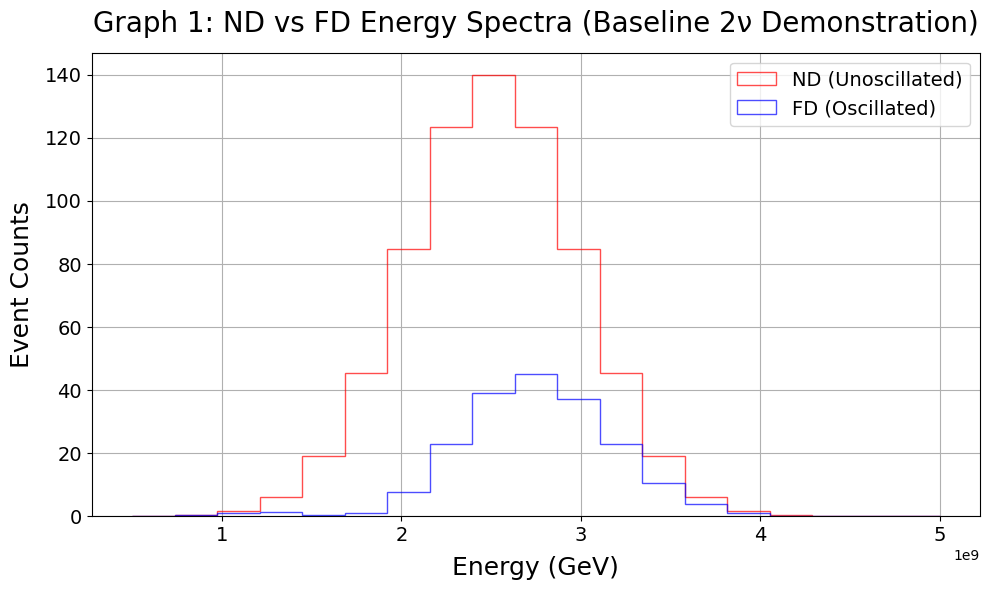

In [4]:
plt.figure(figsize=(10, 6))

plt.hist(bin_edges[:-1], bins=bin_edges, weights=counts_nd,
         histtype='step', color='red', alpha=0.7, label='ND (Unoscillated)')
plt.hist(bin_edges[:-1], bins=bin_edges, weights=counts_fd,
         histtype='step', color='blue', alpha=0.7, label='FD (Oscillated)')

plt.xlabel("Energy (GeV)",  fontsize=18, labelpad=8)    # labelpad adds a bit of spacing
plt.ylabel("Event Counts",  fontsize=18, labelpad=8)
plt.title("Graph 1: ND vs FD Energy Spectra (Baseline 2ν Demonstration)",
          fontsize=20, pad=15)

plt.tick_params(axis='both', which='major', labelsize=14)   # enlarge tick numbers
plt.legend(fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


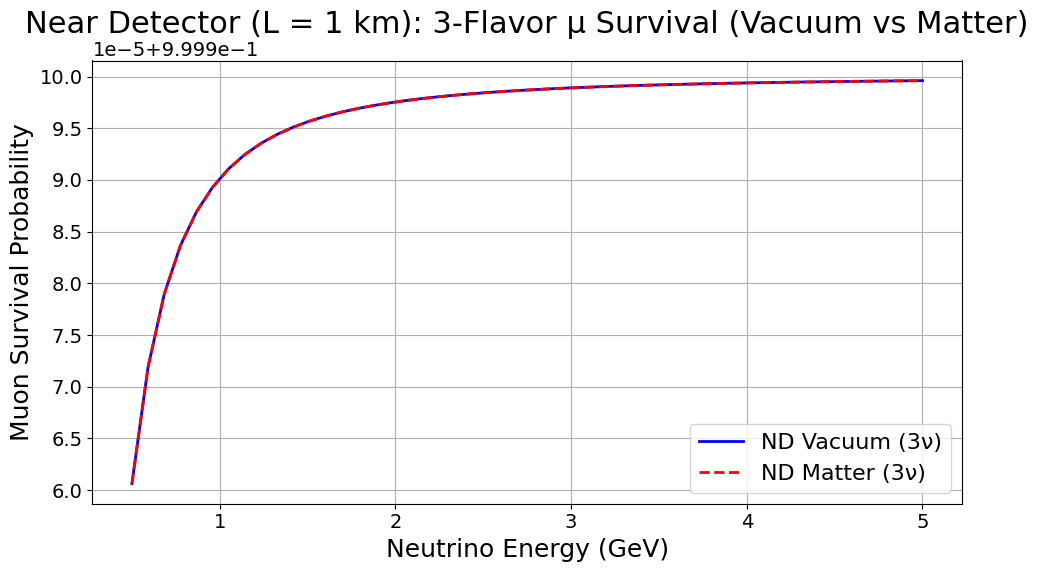

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.linalg import expm

# Global Constants
CONV_KM_TO_INV_EV = 5.067731e9  # km to 1/eV conversion factor
VCC_EARTH_CRUST = 7.6e-14       # Matter potential (eV)

# 3-Flavor (3ν) Parameters (angles in radians)
theta12 = np.radians(33.82)
theta13 = np.radians(8.61)
theta23 = np.radians(48.3)
delta13 = 0                   # CP phase (modify to test CP effects)
D21 = 7.39e-5                 # Solar mass-squared difference (eV²)
D31 = 2.525e-3                # Atmospheric mass-squared difference (eV²)

# Detector Baseline
Length_near = 1  # Near detector baseline in km

# Define Energy Range: from 0.5 GeV to 5 GeV
energies_GeV = np.linspace(0.5, 5, 50)
energies_eV = energies_GeV * 1e9

# Define the 3ν mixing matrix
def mixing_matrix_3nu(theta12, theta13, theta23, delta):
    c12, c13, c23 = np.cos([theta12, theta13, theta23])
    s12, s13, s23 = np.sin([theta12, theta13, theta23])
    U = np.array([
        [c12 * c13, s12 * c13, s13 * np.exp(-1j * delta)],
        [-s12 * c23 - c12 * s13 * s23 * np.exp(1j * delta),
         c12 * c23 - s12 * s13 * s23 * np.exp(1j * delta),
         c13 * s23],
        [s12 * s23 - c12 * s13 * c23 * np.exp(1j * delta),
         -c12 * s23 - s12 * s13 * c23 * np.exp(1j * delta),
         c13 * c23]
    ])
    return U

# 3ν Hamiltonian in vacuum
def hamiltonian_3nu_vacuum(E):
    m2_diag = np.diag([0, D21, D31])
    U = mixing_matrix_3nu(theta12, theta13, theta23, delta13)
    return U @ m2_diag @ np.conjugate(U.T) / (2 * E)

# 3ν muon survival probability: νμ → νμ
def probability_3nu(energy, L, transition='mm', matter=False):
    H = hamiltonian_3nu_vacuum(energy)
    # Include matter effects by adding the matter potential to the νe component
    if matter:
        H = H + np.diag([VCC_EARTH_CRUST, 0, 0])
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    if transition == 'mm':  # muon survival: element (1,1)
        return np.abs(S[1, 1])**2
    # (Other channels such as 'me' or 'mt' could be defined similarly)
    return None

# Calculate probabilities for the near detector in both vacuum and matter
probs_nd_vac = [probability_3nu(E, Length_near, transition='mm', matter=False) for E in energies_eV]
probs_nd_mat = [probability_3nu(E, Length_near, transition='mm', matter=True) for E in energies_eV]


mpl.rcParams.update({
    "figure.figsize":   (10, 6),  # default fig size
    "font.size":        16,       # base font
    "axes.titlesize":   22,       # main title
    "axes.labelsize":   18,       # x & y labels
    "xtick.labelsize":  14,
    "ytick.labelsize":  14,
    "legend.fontsize":  16,
    "grid.linewidth":   0.8
})

# Plotting ND 3ν muon survival probability: Vacuum vs Matter
plt.figure()                                    # figsize already set above
plt.plot(energies_GeV, probs_nd_vac, 'b-',  lw=2, label='ND Vacuum (3ν)')
plt.plot(energies_GeV, probs_nd_mat, 'r--', lw=2, label='ND Matter (3ν)')

plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Muon Survival Probability")
plt.title("Near Detector (L = 1 km): 3‑Flavor μ Survival (Vacuum vs Matter)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

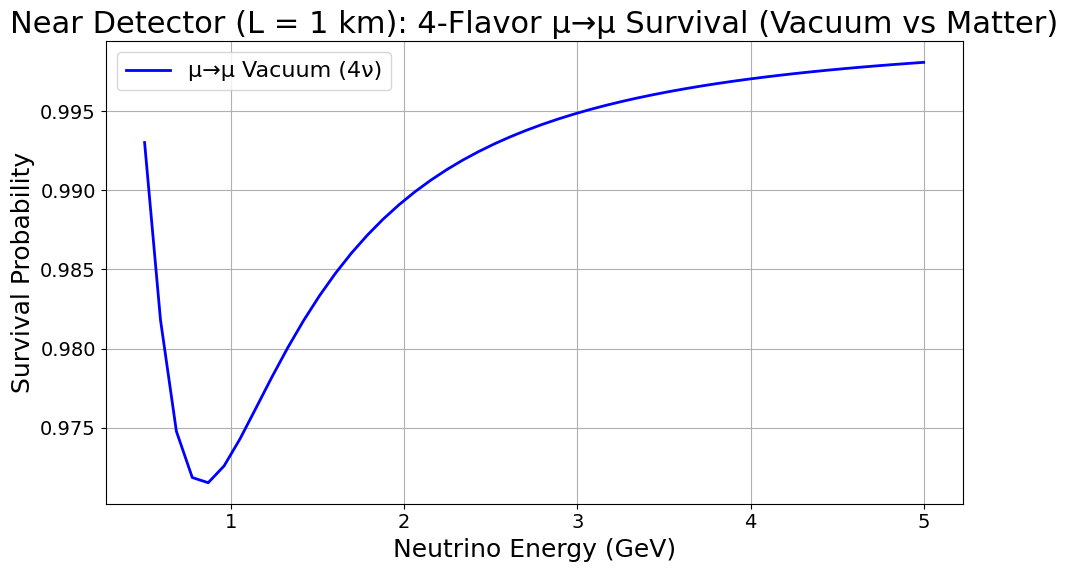

In [6]:
# Define energy range in GeV and convert to eV
energies_GeV = np.linspace(0.5, 5, 50)
energies_eV = energies_GeV * 1e9

# Near detector baseline in km
Length_near = 1

# Calculate μ→μ survival probability for 4-flavor in vacuum and in matter
probs_4nu_mm_vac = [probability_4nu(E, Length_near, transition='mm', case='vacuum') for E in energies_eV]
probs_4nu_mm_mat = [probability_4nu(E, Length_near, transition='mm', case='matter') for E in energies_eV]

plt.figure()                                           # figsize handled by rcParams
plt.plot(energies_GeV, probs_4nu_mm_vac,
         'b-', lw=2, label="μ→μ Vacuum (4ν)")

plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Survival Probability")
plt.title("Near Detector (L = 1 km): 4‑Flavor μ→μ Survival (Vacuum vs Matter)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

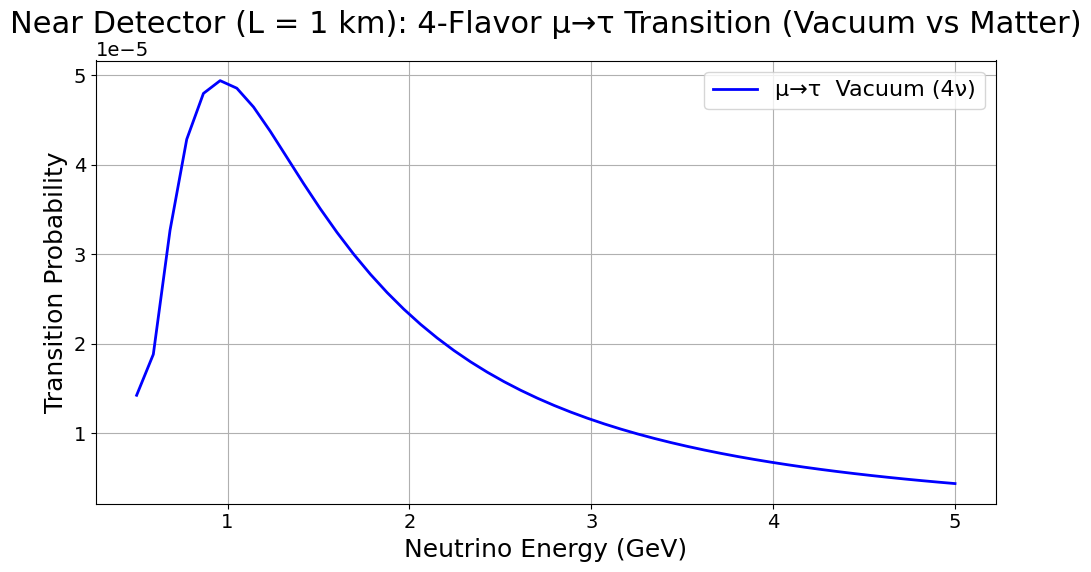

In [7]:
# Calculate μ→τ transition probability for 4-flavor in vacuum and in matter (ND)
probs_4nu_mt_vac = [probability_4nu(E, Length_near, transition='mt', case='vacuum') for E in energies_eV]
probs_4nu_mt_mat = [probability_4nu(E, Length_near, transition='mt', case='matter') for E in energies_eV]

plt.figure()                                          # figsize handled by rcParams
plt.plot(energies_GeV, probs_4nu_mt_vac,
         'b-', lw=2, label="μ→τ  Vacuum (4ν)")

plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Transition Probability")
plt.title("Near Detector (L = 1 km): 4‑Flavor μ→τ Transition (Vacuum vs Matter)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

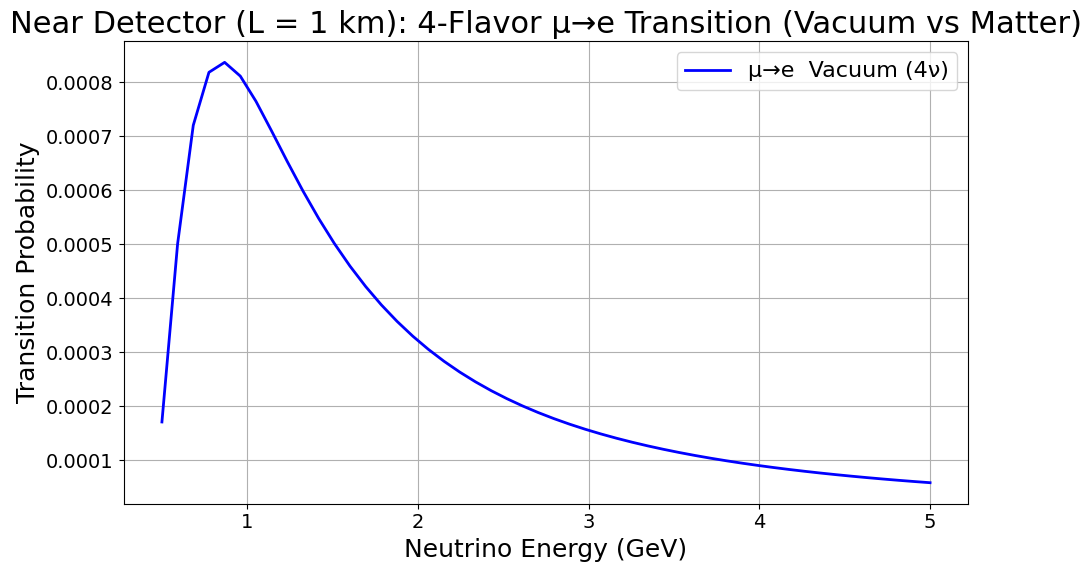

In [8]:
# Calculate μ→e transition probability for 4-flavor in vacuum and in matter (ND)
probs_4nu_me_vac = [probability_4nu(E, Length_near, transition='me', case='vacuum') for E in energies_eV]
probs_4nu_me_mat = [probability_4nu(E, Length_near, transition='me', case='matter') for E in energies_eV]

# 4‑flavor μ→e transition probability – Near Detector
plt.figure()                       # global rcParams handle size & fonts
plt.plot(
    energies_GeV,
    probs_4nu_me_vac,
    "b-",
    lw=2,
    label="μ→e  Vacuum (4ν)"
)

plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Transition Probability")
plt.title("Near Detector (L = 1 km): 4‑Flavor μ→e Transition (Vacuum vs Matter)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

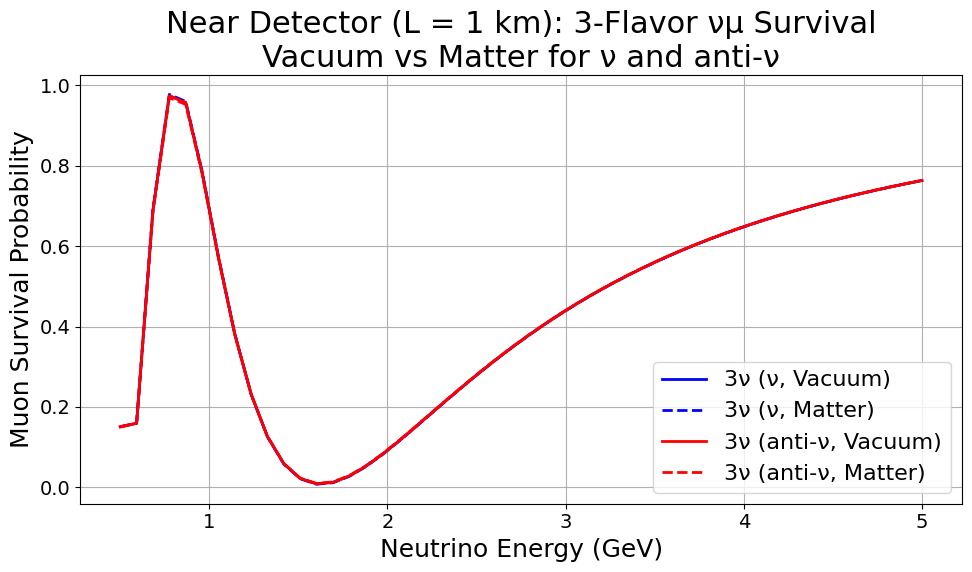

In [9]:
probs_3nu_vac = [probability_3nu(E, Length_far, transition='mm', matter=False) for E in energies_eV]
probs_3nu_mat = [probability_3nu(E, Length_far, transition='mm', matter=True) for E in energies_eV]
probs_3nu_antinue_vac = [probability_3nu_antinue(E, Length_far, transition='mm', matter=False) for E in energies_eV]
probs_3nu_antinue_mat = [probability_3nu_antinue(E, Length_far, transition='mm', matter=True) for E in energies_eV]

plt.figure()                                    # size is handled via rcParams

plt.plot(energies_GeV, probs_3nu_vac,          "b-",  lw=2,
         label="3ν (ν, Vacuum)")
plt.plot(energies_GeV, probs_3nu_mat,          "b--", lw=2,
         label="3ν (ν, Matter)")
plt.plot(energies_GeV, probs_3nu_antinue_vac,  "r-",  lw=2,
         label="3ν (anti‑ν, Vacuum)")
plt.plot(energies_GeV, probs_3nu_antinue_mat,  "r--", lw=2,
         label="3ν (anti‑ν, Matter)")

plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Muon Survival Probability")
plt.title("Near Detector (L = 1 km): 3‑Flavor νμ Survival\n"
          "Vacuum vs Matter for ν and anti‑ν")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

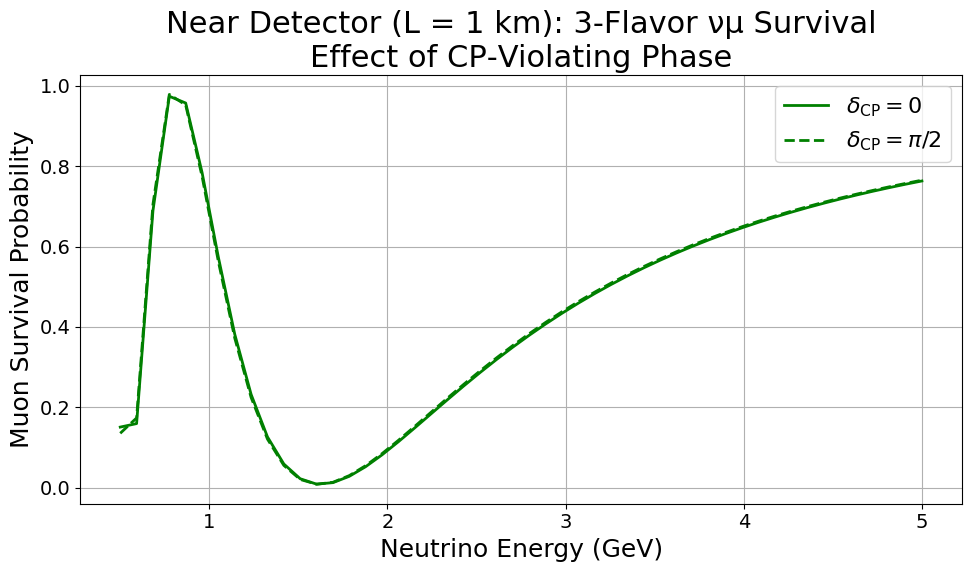

In [10]:
def probability_3nu_cp(energy, L, delta):
    U = mixing_matrix_3nu(theta12, theta13, theta23, delta)
    m2 = np.diag([0, D21, D31])
    H = U @ m2 @ np.conjugate(U.T) / (2 * energy)
    S = expm(-1j * H * L * CONV_KM_TO_INV_EV)
    return np.abs(S[1, 1])**2

probs_cp0 = [probability_3nu_cp(E, Length_far, 0) for E in energies_eV]
probs_cppi2 = [probability_3nu_cp(E, Length_far, np.pi/2) for E in energies_eV]

plt.figure()                       # global figsize & font already set

plt.plot(energies_GeV, probs_cp0,   "g-",  lw=2, label=r"$\delta_{\rm CP}=0$")
plt.plot(energies_GeV, probs_cppi2, "g--", lw=2, label=r"$\delta_{\rm CP}=\pi/2$")

plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Muon Survival Probability")
plt.title("Near Detector (L = 1 km): 3‑Flavor νμ Survival\n"
          "Effect of CP‑Violating Phase")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


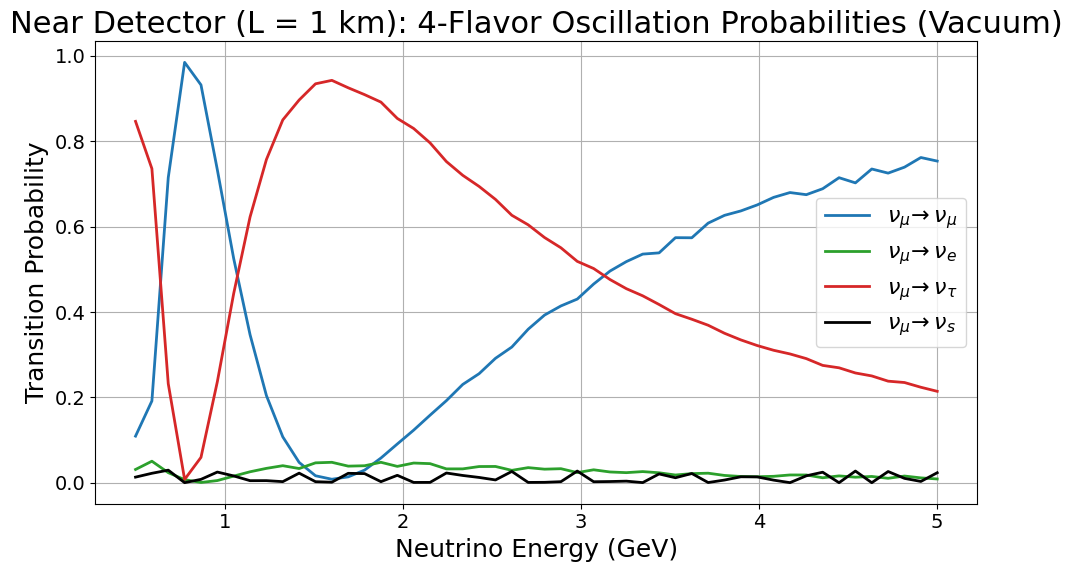

In [11]:
probs_4nu_mm = [probability_4nu(E, Length_far, transition='mm', case='vacuum') for E in energies_eV]
probs_4nu_me = [probability_4nu(E, Length_far, transition='me', case='vacuum') for E in energies_eV]
probs_4nu_mt = [probability_4nu(E, Length_far, transition='mt', case='vacuum') for E in energies_eV]
probs_4nu_ms = [probability_4nu(E, Length_far, transition='ms', case='vacuum') for E in energies_eV]

plt.figure()                                    # uses the global figsize & fonts

# — 4‑flavor oscillation channels (vacuum) —
plt.plot(energies_GeV, probs_4nu_mm, color="tab:blue",  lw=2,
         label=r"$\nu_\mu\!\to\nu_\mu$")
plt.plot(energies_GeV, probs_4nu_me, color="tab:green", lw=2,
         label=r"$\nu_\mu\!\to\nu_e$")
plt.plot(energies_GeV, probs_4nu_mt, color="tab:red",   lw=2,
         label=r"$\nu_\mu\!\to\nu_\tau$")
plt.plot(energies_GeV, probs_4nu_ms, color="black",     lw=2,
         label=r"$\nu_\mu\!\to\nu_s$")

plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Transition Probability")
plt.title("Near Detector (L = 1 km): 4‑Flavor Oscillation Probabilities (Vacuum)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

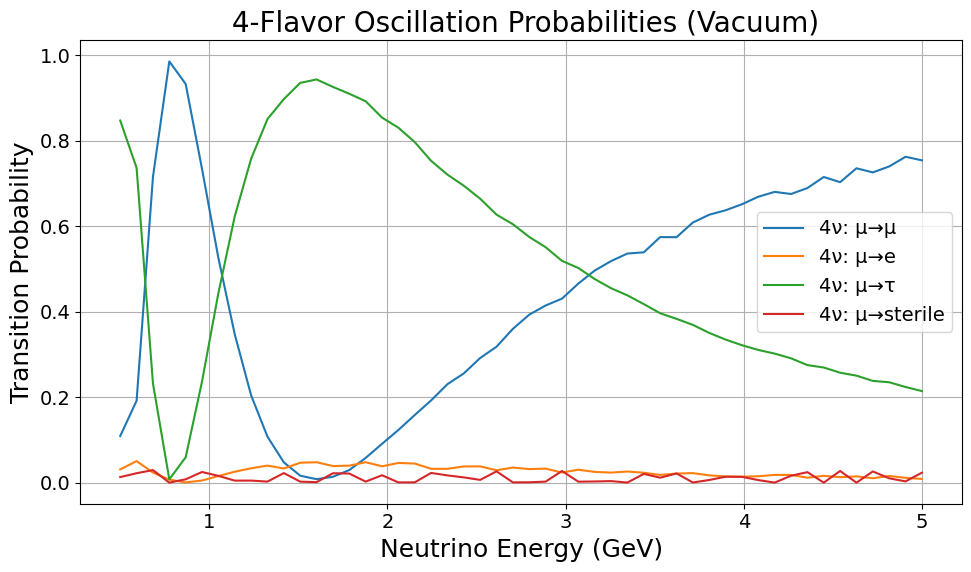

In [12]:
plt.figure(figsize=(10,6))

plt.plot(energies_GeV, probs_4nu_mm, label='4ν: μ→μ')
plt.plot(energies_GeV, probs_4nu_me, label='4ν: μ→e')
plt.plot(energies_GeV, probs_4nu_mt, label='4ν: μ→τ')
plt.plot(energies_GeV, probs_4nu_ms, label='4ν: μ→sterile')

plt.xlabel("Neutrino Energy (GeV)", fontsize=18)
plt.ylabel("Transition Probability",   fontsize=18)
plt.title(" 4‑Flavor Oscillation Probabilities (Vacuum)", fontsize=20)

plt.tick_params(axis='both', labelsize=14)   # larger tick numbers
plt.legend(fontsize=14)                      # larger legend text
plt.grid(True)
plt.tight_layout()
plt.show()

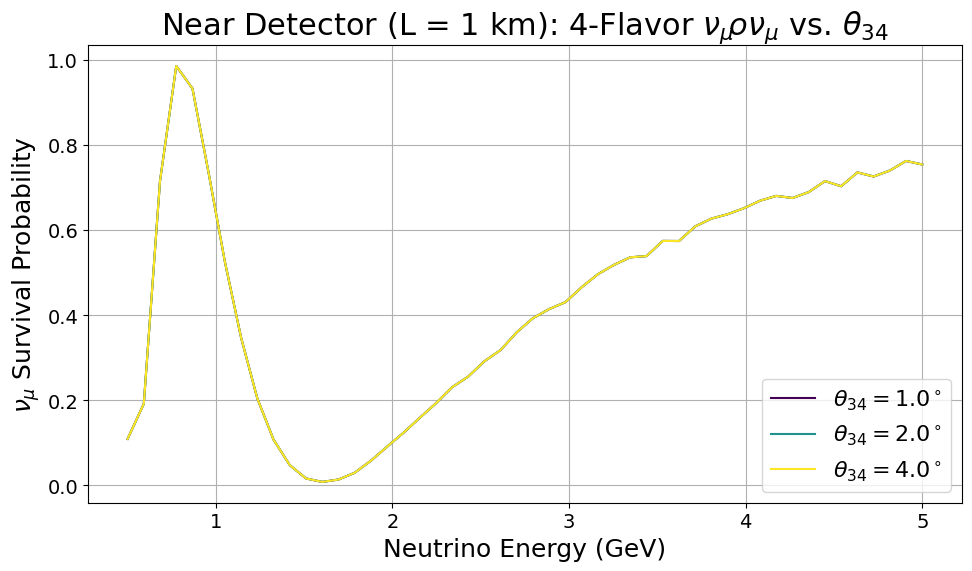

In [13]:
theta34_vals = [np.radians(1), np.radians(2), np.radians(4)]
# ── θ34 scan plot ─────────────────────────────────────────────────────────
plt.figure()                         # inherits figsize & fonts above

cmap   = mpl.cm.viridis              # colour map to cycle through
colors = cmap(np.linspace(0, 1, len(theta34_vals)))

for colour, th34 in zip(colors, theta34_vals):
    theta34_current = th34           # (or call a setter in your prob. code)
    prob_mm = [probability_4nu(E, Length_far,
                               transition="mm",
                               case="vacuum")
               for E in energies_eV]

    label = rf"$\theta_{{34}} = {np.degrees(th34):.1f}^\circ$"
    plt.plot(energies_GeV, prob_mm, color=colour, label=label)

plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel(r"$\nu_\mu$ Survival Probability")
plt.title("Near Detector (L = 1 km): 4‑Flavor $\\nu_\\mu\\!\to\\nu_\\mu$ vs. $\\theta_{34}$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

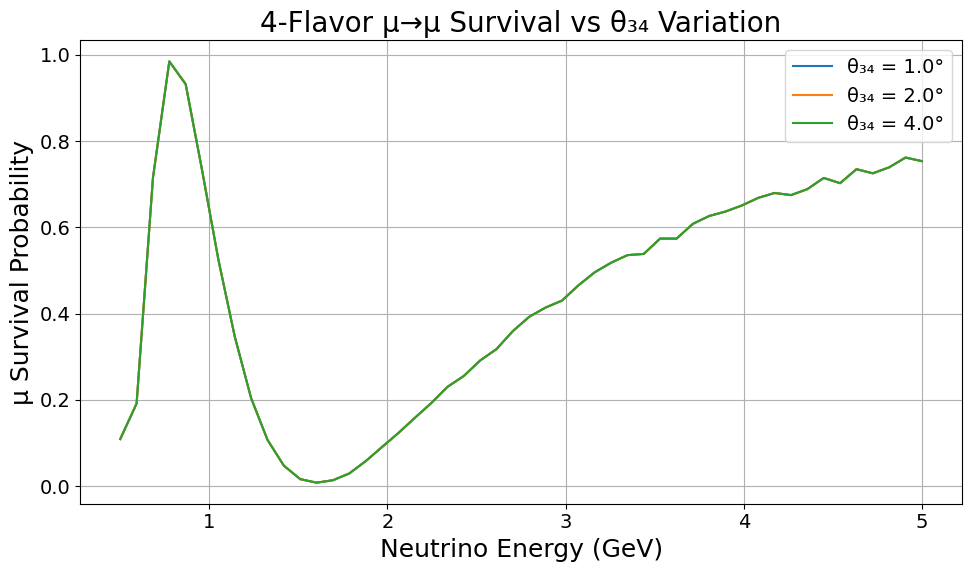

In [14]:
plt.figure(figsize=(10,6))

for th34 in theta34_vals:
    theta34_current = th34
    prob_mm = [probability_4nu(E, Length_far,
                               transition='mm',
                               case='vacuum')
               for E in energies_eV]
    plt.plot(energies_GeV, prob_mm,
             label=f"θ₃₄ = {np.degrees(th34):.1f}°")

# ⬇️  only these four lines are new
plt.xlabel("Neutrino Energy (GeV)", fontsize=18)
plt.ylabel("μ Survival Probability",   fontsize=18)
plt.title("4‑Flavor μ→μ Survival vs θ₃₄ Variation",
          fontsize=20)
plt.tick_params(axis='both', labelsize=14)   # bigger tick labels
plt.legend(fontsize=14)                      # bigger legend text
plt.grid(True)
plt.tight_layout()
plt.show()

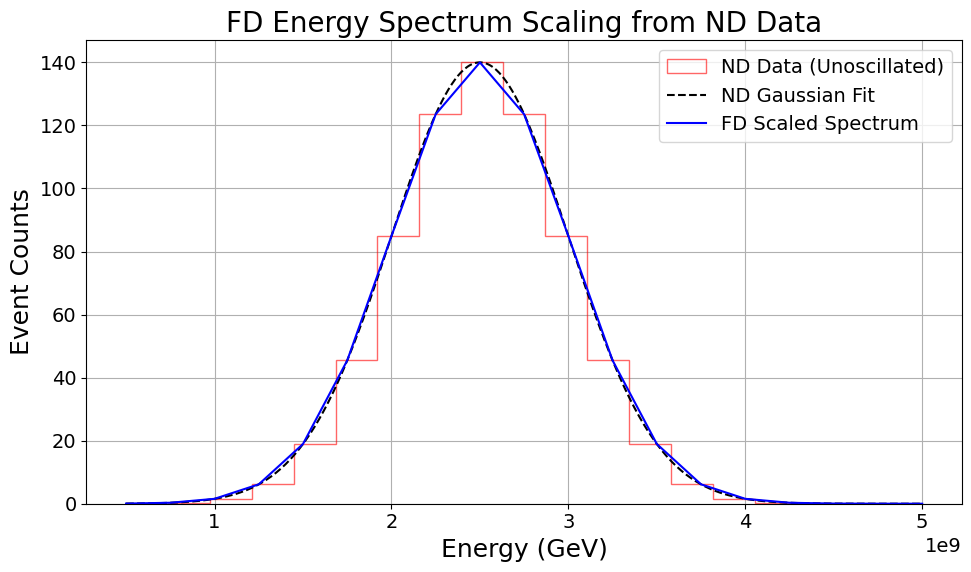

In [15]:
# Example scaling factor from your dictionary (using neutrino mode, no specific subchannel)
scaling_factors = {('antineutrino', 3): 0.8, ('antineutrino', None): 0.5,
                   ('neutrino', 3): 1.2, ('neutrino', None): 1.0}
scale_factor = scaling_factors[('neutrino', None)]
# Scale the ND Gaussian spectrum to create a dummy FD spectrum
oscillated_fd_scaled = gaussian(bin_centers, *popt_nd) * scale_factor

plt.figure(figsize=(10,6))

plt.hist(
    bin_edges[:-1],
    bins=bin_edges,
    weights=counts_nd,
    histtype='step',
    color='red',
    alpha=0.6,
    label='ND Data (Unoscillated)'
)

x_vals = np.linspace(bin_centers[0], bin_centers[-1], 500)
plt.plot(x_vals, gaussian(x_vals, *popt_nd), 'k--', label='ND Gaussian Fit')
plt.plot(bin_centers, oscillated_fd_scaled, 'b-', label='FD Scaled Spectrum')

plt.xlabel("Energy (GeV)",  fontsize=18)
plt.ylabel("Event Counts",   fontsize=18)
plt.title("FD Energy Spectrum Scaling from ND Data", fontsize=20)

plt.tick_params(axis='both', labelsize=14)   # bigger tick labels
plt.legend(fontsize=14)                      # bigger legend text
plt.grid(True)
plt.tight_layout()
plt.show()

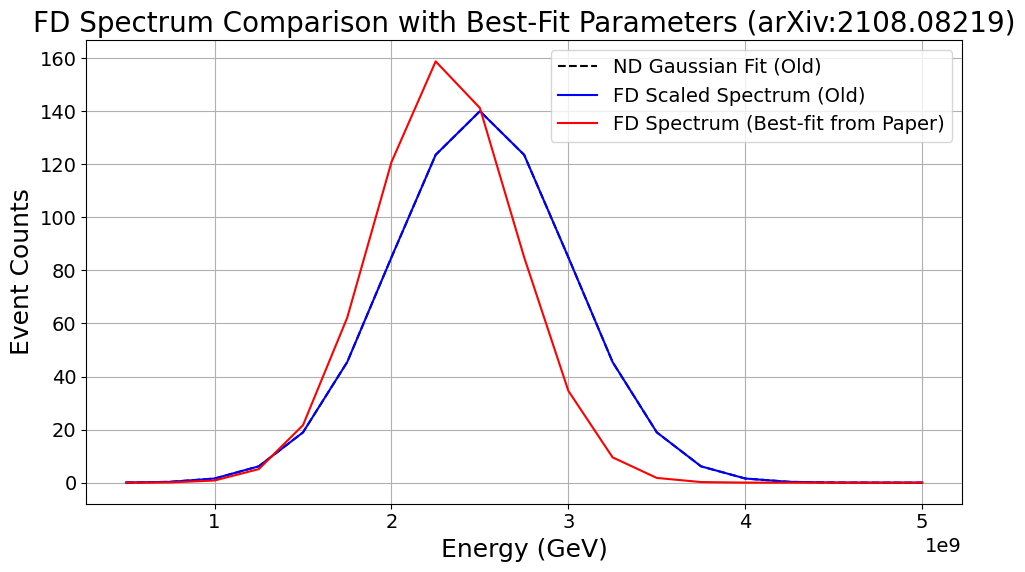

In [16]:
# Alternative Gaussian parameters from a paper (example values)
popt_best = [160, 2.3e9, 0.4e9]  # amplitude, mean, sigma
oscillated_fd_best = gaussian(bin_centers, *popt_best)

plt.figure(figsize=(10,6))

plt.plot(bin_centers,
         gaussian(bin_centers, *popt_nd),
         'k--',
         label='ND Gaussian Fit (Old)')

plt.plot(bin_centers,
         oscillated_fd_scaled,
         'b-',
         label='FD Scaled Spectrum (Old)')

plt.plot(bin_centers,
         oscillated_fd_best,
         'r-',
         label='FD Spectrum (Best‑fit from Paper)')

plt.xlabel("Energy (GeV)",   fontsize=18)
plt.ylabel("Event Counts",    fontsize=18)
plt.title("FD Spectrum Comparison with Best‑Fit Parameters (arXiv:2108.08219)",
          fontsize=20)

plt.tick_params(axis='both', labelsize=14)   # larger tick labels
plt.legend(fontsize=14)                      # larger legend text
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
#2 flavour focus here on

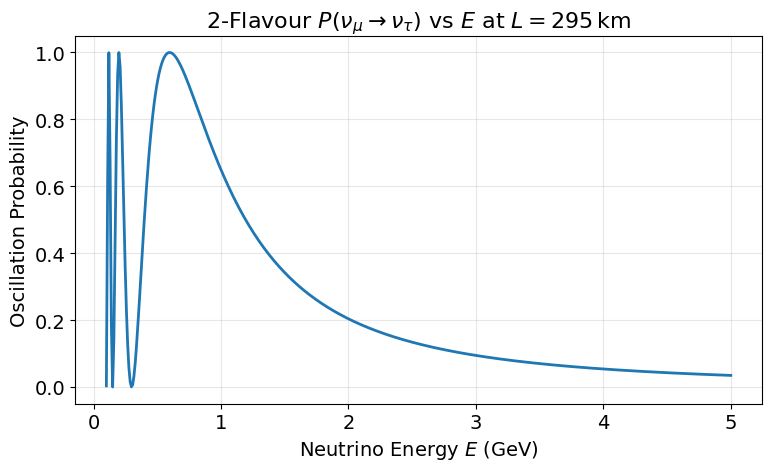

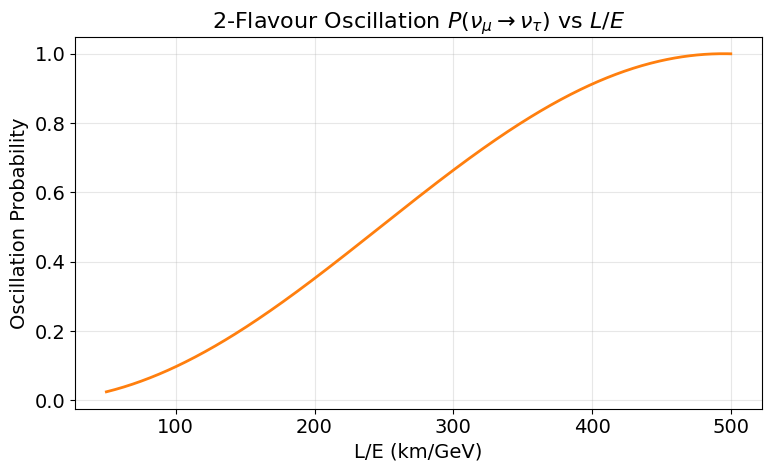

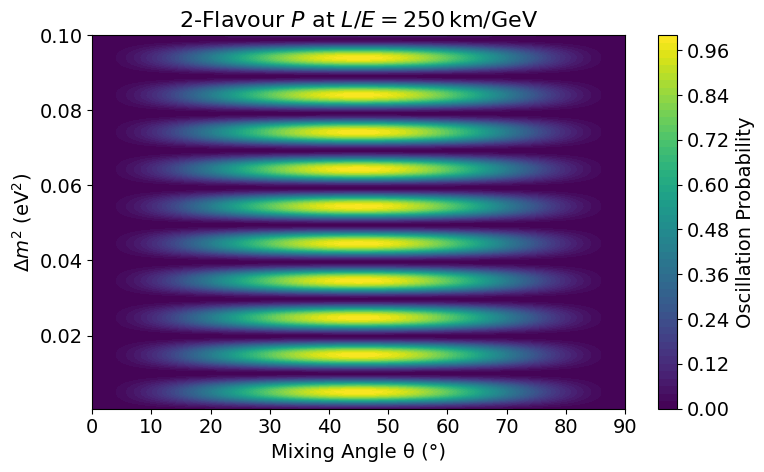

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# Two‐flavour oscillation probability function
# ----------------------------------------
def two_flavour_prob(theta, delta_m2, L, E):
    """
    Two‐flavour oscillation:
      P(ν_μ → ν_τ) = sin²(2θ) * sin²[1.27 Δm² L / E]
    Inputs:
      theta     -> mixing angle (radians)
      delta_m2  -> mass‐splitting in eV²
      L         -> baseline in km
      E         -> neutrino energy in GeV (can be array)
    """
    return np.sin(2*theta)**2 * np.sin(1.27 * delta_m2 * L / E)**2

# Choose some “typical” values
delta_m2  = 2.5e-3     # Δm² = 2.5×10⁻³ eV²
theta_deg = 45         # θ = 45°
theta     = np.radians(theta_deg)

# 1) P vs E at fixed L
L_fixed   = 295        # km (e.g. T2K baseline)
E_vals    = np.linspace(0.1, 5, 500)   # 0.1–5 GeV
P_E       = two_flavour_prob(theta, delta_m2, L_fixed, E_vals)

plt.figure(figsize=(8,5))
plt.plot(E_vals, P_E, lw=2, color='C0')
plt.xlabel("Neutrino Energy $E$ (GeV)", fontsize=14)
plt.ylabel("Oscillation Probability",    fontsize=14)
plt.title(f"2‑Flavour $P(\\nu_μ\\to\\nu_τ)$ vs $E$ at $L={L_fixed}\\,$km", fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 2) P vs L/E
LE_vals = np.linspace(50, 500, 500)   # 50–500 km/GeV
P_LE    = two_flavour_prob(theta, delta_m2, 1, E=1/LE_vals*1)  # Actually sin²(...) only depends on L/E

# More direct formula: P(LE) = sin²2θ * sin²[1.27 Δm² × (L/E)]
P_LE = np.sin(2*theta)**2 * np.sin(1.27 * delta_m2 * LE_vals)**2

plt.figure(figsize=(8,5))
plt.plot(LE_vals, P_LE, lw=2, color='C1')
plt.xlabel("L/E (km/GeV)", fontsize=14)
plt.ylabel("Oscillation Probability",    fontsize=14)
plt.title("2‑Flavour Oscillation $P(\\nu_μ\\to\\nu_τ)$ vs $L/E$", fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 3) Contour of P in the (θ, Δm²) plane at fixed L/E
theta_grid   = np.linspace(0, np.pi/2, 200)      # 0–90°
delta_m2_grid= np.linspace(5e-4, 1e-1, 200)     # 5×10⁻⁴–0.1 eV²
LE_fixed     = 250                              # km/GeV
Θ, DM2        = np.meshgrid(theta_grid, delta_m2_grid)
P_contour    = np.sin(2*Θ)**2 * np.sin(1.27 * DM2 * LE_fixed)**2

plt.figure(figsize=(8,5))
cs = plt.contourf(
    np.degrees(Θ), DM2, P_contour,
    levels=50, cmap='viridis'
)
cbar = plt.colorbar(cs)
cbar.set_label("Oscillation Probability", fontsize=14)
plt.xlabel("Mixing Angle θ (°)",     fontsize=14)
plt.ylabel(r"$\Delta m^2$ (eV$^2$)", fontsize=14)
plt.title(f"2‑Flavour $P$ at $L/E={LE_fixed}\\,$km/GeV", fontsize=16)
plt.tight_layout()
plt.show()


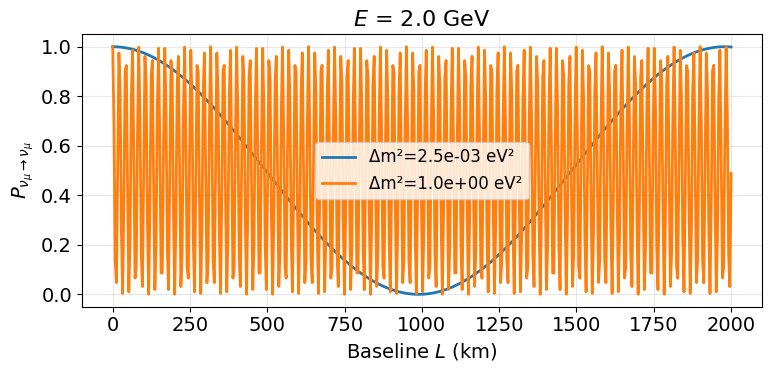

In [19]:
# two‑flavor survival
def P_surv(E, L, dmsq=2.5e-3, theta=45):
    θ = np.radians(theta)
    arg = 1.27 * dmsq * L / E
    return 1 - np.sin(2*θ)**2 * np.sin(arg)**2

E_fixed = 2.0  # GeV
Ls = np.linspace(0, 2000, 500)  # km

plt.figure(figsize=(8,4))
for dmsq, col in [(2.5e-3,'C0'), (1.0,'C1')]:
    plt.plot(Ls, P_surv(E_fixed, Ls, dmsq=dmsq),
             label=f'Δm²={dmsq:.1e} eV²', color=col, lw=2)
plt.xlabel("Baseline $L$ (km)",       fontsize=14)
plt.ylabel(r"$P_{\nu_\mu\to\nu_\mu}$",fontsize=14)
plt.title(f"$E$ = {E_fixed} GeV",     fontsize=16)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

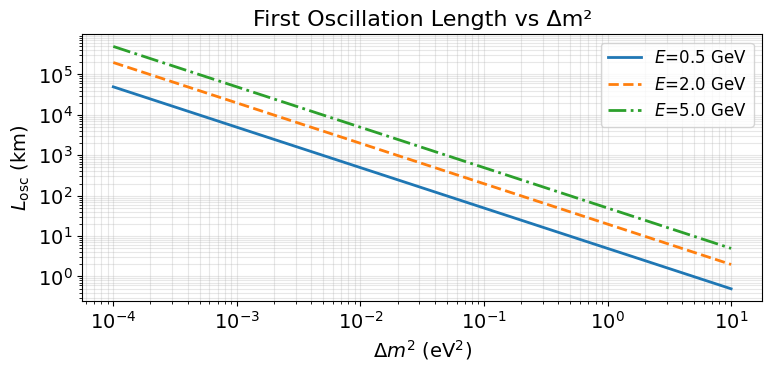

In [20]:
def L_osc(E, dmsq):
    return (4*np.pi * E) / (1.27 * dmsq)

dmsqs = np.logspace(-4, 1, 200)  # 1e-4 … 10 eV²
plt.figure(figsize=(8,4))
for E, style in [(0.5,'-'), (2.0,'--'), (5.0,'-.')]:
    plt.loglog(dmsqs, L_osc(E, dmsqs), style, lw=2,
               label=f'$E$={E} GeV')
plt.xlabel(r'$\Delta m^2$ (eV$^2$)', fontsize=14)
plt.ylabel(r'$L_{\rm osc}$ (km)',      fontsize=14)
plt.title("First Oscillation Length vs Δm²", fontsize=16)
plt.legend(fontsize=12)
plt.grid(which='both', alpha=0.3)
plt.tight_layout()
plt.show()

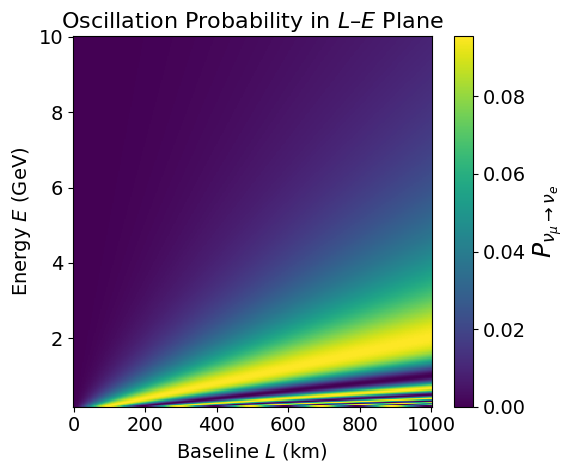

In [21]:
# two‑flavor appearance
def P_app(E, L, dmsq=2.5e-3, theta=9):  # theta13≈9°
    θ = np.radians(theta)
    arg = 1.27 * dmsq * L / E
    return (np.sin(2*θ)**2) * (np.sin(arg)**2)

Ls = np.linspace(0, 1000, 300)
Es = np.linspace(0.2, 10,   300)
LL, EE = np.meshgrid(Ls, Es)
PP = P_app(EE, LL)

plt.figure(figsize=(6,5))
im = plt.pcolormesh(LL, EE, PP, cmap='viridis', shading='auto')
cbar = plt.colorbar(im, label=r'$P_{\nu_\mu\to\nu_e}$')
plt.xlabel("Baseline $L$ (km)", fontsize=14)
plt.ylabel("Energy $E$ (GeV)", fontsize=14)
plt.title("Oscillation Probability in $L$–$E$ Plane", fontsize=16)
plt.tight_layout()
plt.show()

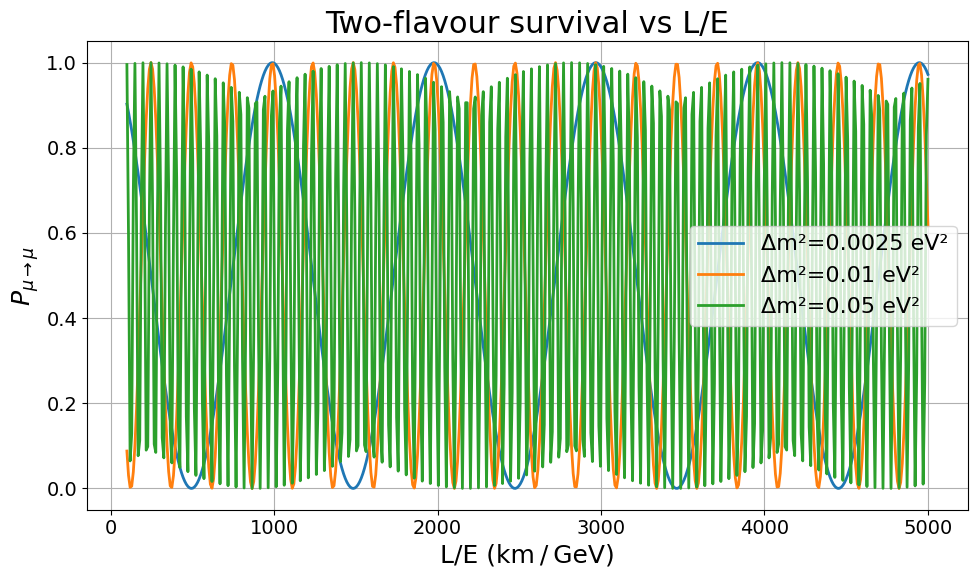

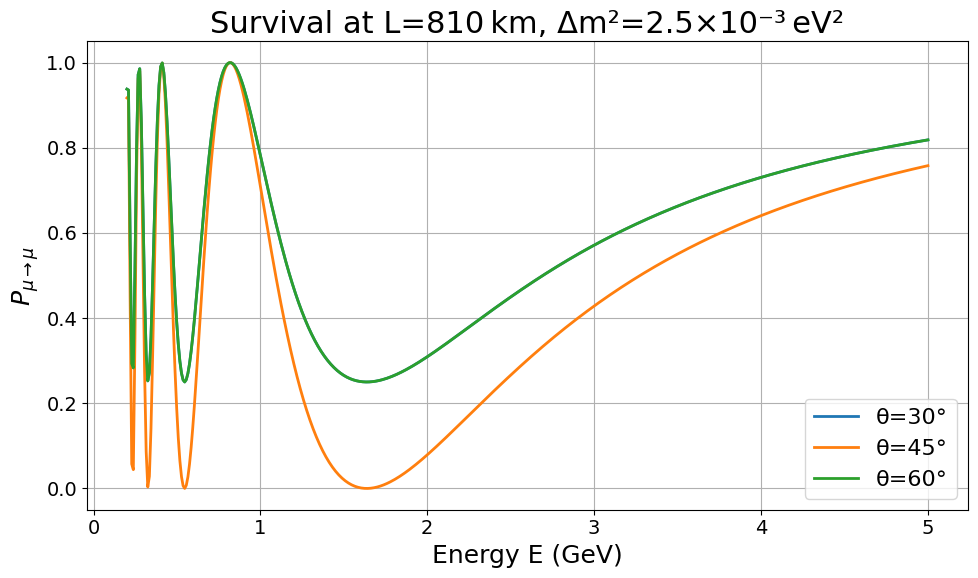

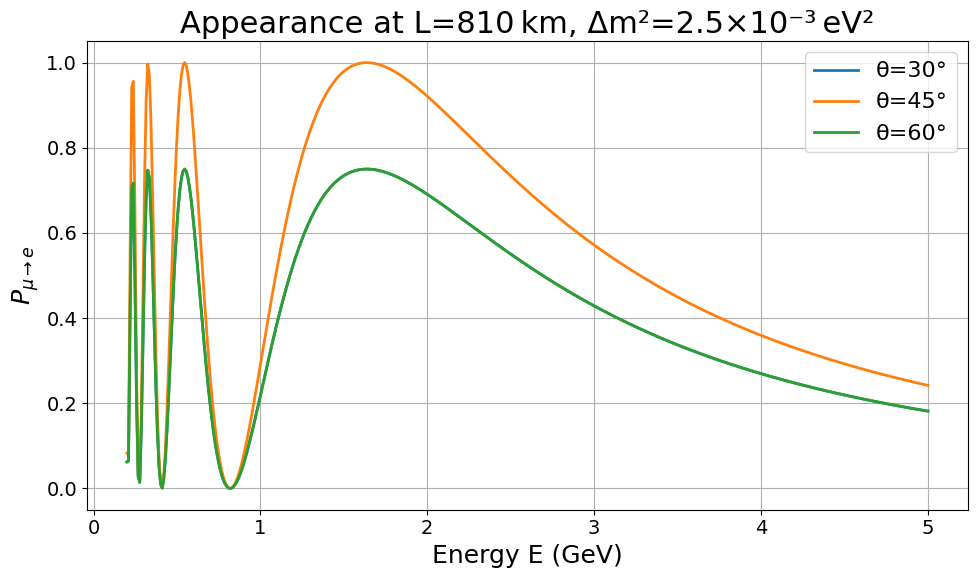

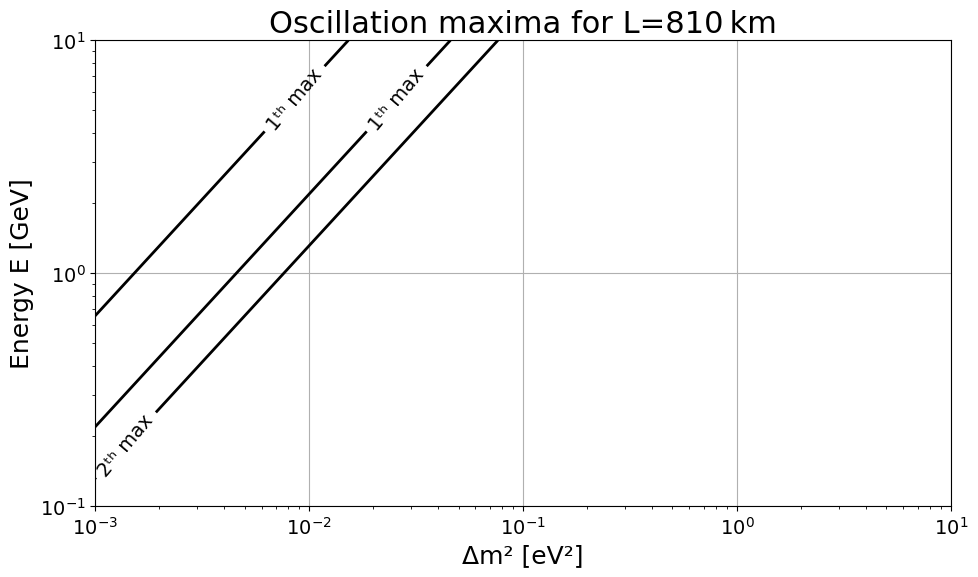

In [22]:
# two‑flavour survival and appearance
def P_surv(E, L, dm2, theta):
    x = 1.27 * dm2 * L / E
    return 1 - np.sin(2*theta)**2 * np.sin(x)**2

def P_app(E, L, dm2, theta):
    x = 1.27 * dm2 * L / E
    return       np.sin(2*theta)**2 * np.sin(x)**2

# common plotting defaults
plt.rcParams.update({
    "figure.figsize": (10,6),
    "font.size":      14,
    "lines.linewidth": 2,
    "axes.grid":     True,
})

# 1) P_surv vs L/E for different Δm²
LE = np.linspace(100, 5000, 500)   # km/GeV
the = np.deg2rad(45)               # 45° mixing
for dm2 in [2.5e-3, 1e-2, 5e-2]:
    plt.plot(LE, P_surv(1, LE, dm2, the),
             label=f'Δm²={dm2:.3g} eV²')
plt.xlabel("L/E (km / GeV)")
plt.ylabel(r'$P_{\mu\to\mu}$')
plt.title("Two‑flavour survival vs L/E")
plt.legend()
plt.tight_layout()
plt.show()

# 2) P_surv vs E at fixed L
E = np.linspace(0.2, 5, 500)
L = 810  # km
for th_deg in [30, 45, 60]:
    th = np.deg2rad(th_deg)
    plt.plot(E, P_surv(E, L, dm2=2.5e-3, theta=th),
             label=f'θ={th_deg}°')
plt.xlabel("Energy E (GeV)")
plt.ylabel(r'$P_{\mu\to\mu}$')
plt.title(f"Survival at L={L} km, Δm²=2.5×10⁻³ eV²")
plt.legend()
plt.tight_layout()
plt.show()

# 3) P_app vs E at fixed L
for th_deg in [30, 45, 60]:
    th = np.deg2rad(th_deg)
    plt.plot(E, P_app(E, L, dm2=2.5e-3, theta=th),
             label=f'θ={th_deg}°')
plt.xlabel("Energy E (GeV)")
plt.ylabel(r'$P_{\mu\to e}$')
plt.title(f"Appearance at L={L} km, Δm²=2.5×10⁻³ eV²")
plt.legend()
plt.tight_layout()
plt.show()

# 4) Contours of first oscillation maximum: 1.27 dm2 L / E = π/2
dm2_vals = np.logspace(-3, 1, 200)
E_vals   = np.logspace(-1, 1, 200)
DM2, EE  = np.meshgrid(dm2_vals, E_vals)
phase    = 1.27 * DM2 * L / EE
# we contour phase = π/2, 3π/2, …
levels = [np.pi/2, 3*np.pi/2, 5*np.pi/2]
cs = plt.contour(DM2, EE, phase, levels=levels, colors='k')
plt.xscale('log'); plt.yscale('log')
plt.clabel(cs, fmt={lev: f"{int((lev/np.pi - .5)/2)+1}ᵗʰ max" for lev in levels})
plt.xlabel(r'Δm² [eV²]')
plt.ylabel('Energy E [GeV]')
plt.title(f'Oscillation maxima for L={L} km')
plt.tight_layout()
plt.show()

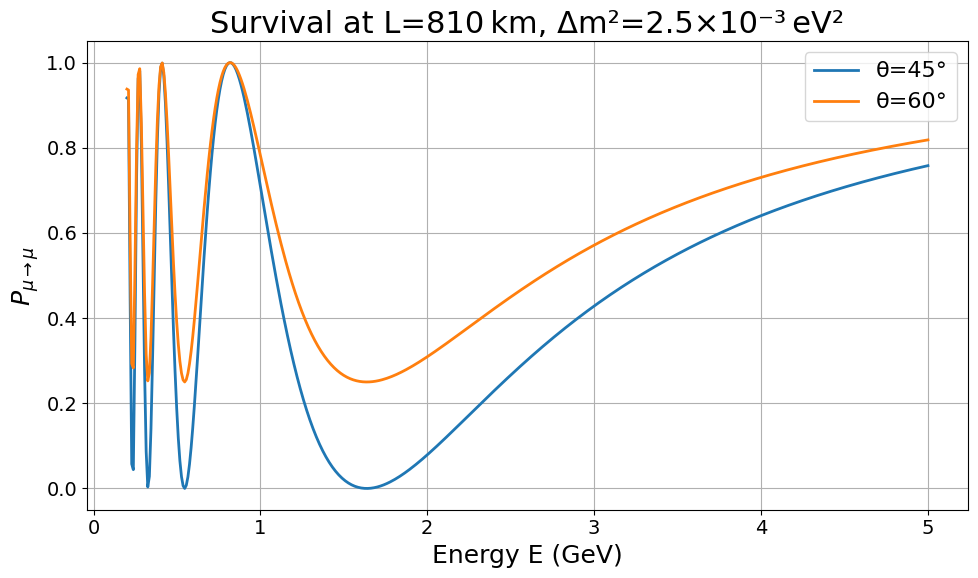

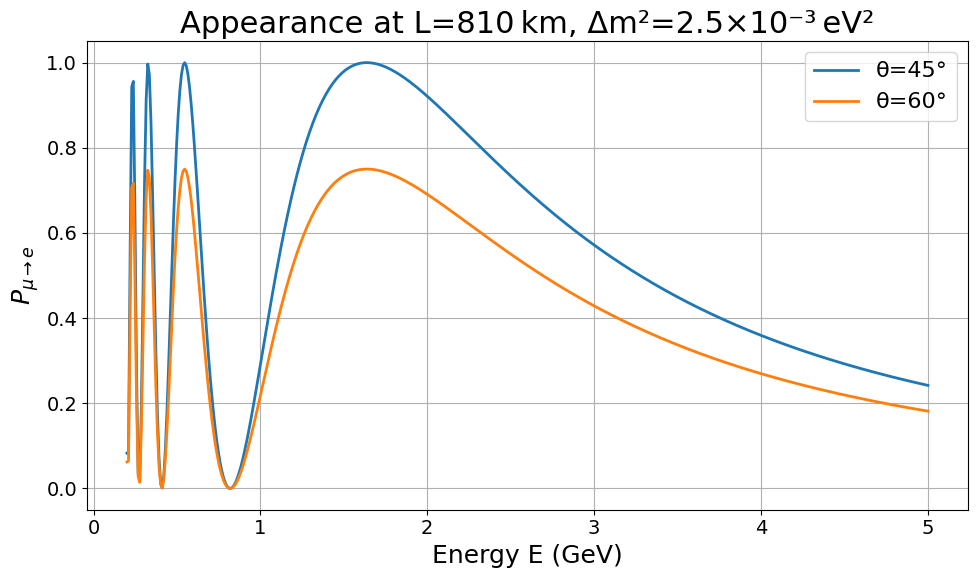

In [34]:
# 2) P_surv vs E at fixed L
E = np.linspace(0.2, 5, 500)
L = 810  # km
for th_deg in [45, 60]:  # Removed 30
    th = np.deg2rad(th_deg)
    plt.plot(E, P_surv(E, L, dm2=2.5e-3, theta=th),
             label=f'θ={th_deg}°')
plt.xlabel("Energy E (GeV)")
plt.ylabel(r'$P_{\mu\to\mu}$')
plt.title(f"Survival at L={L} km, Δm²=2.5×10⁻³ eV²")
plt.legend()
plt.tight_layout()
plt.show()

# 3) P_app vs E at fixed L
for th_deg in [45, 60]:  # Removed 30
    th = np.deg2rad(th_deg)
    plt.plot(E, P_app(E, L, dm2=2.5e-3, theta=th),
             label=f'θ={th_deg}°')
plt.xlabel("Energy E (GeV)")
plt.ylabel(r'$P_{\mu\to e}$')
plt.title(f"Appearance at L={L} km, Δm²=2.5×10⁻³ eV²")
plt.legend()
plt.tight_layout()
plt.show()

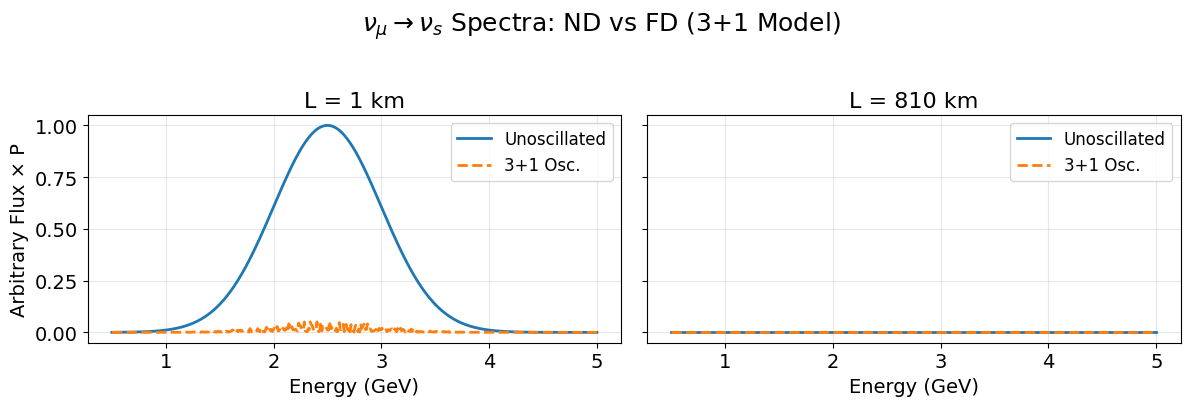

In [23]:
# ----------------------------
# 1) build U_4x4 mixing matrix
# ----------------------------
def U_4x4(theta12, theta13, theta23, theta14, theta24, theta34):
    """Construct 4×4 real mixing matrix with no CP phases."""
    # convert to radians
    t12,t13,t23,t14,t24,t34 = map(np.radians,
        (theta12,theta13,theta23,theta14,theta24,theta34))
    # 3×3 sub-block (standard PMNS, no CP)
    c12,c13,c23 = np.cos(t12), np.cos(t13), np.cos(t23)
    s12,s13,s23 = np.sin(t12), np.sin(t13), np.sin(t23)
    U3 = np.array([
        [ c12*c13,             s12*c13,            s13    ],
        [-s12*c23 - c12*s23*s13,  c12*c23 - s12*s23*s13,  s23*c13],
        [ s12*s23 - c12*c23*s13, -c12*s23 - s12*c23*s13,  c23*c13]
    ])
    # start with identity 4×4
    U = np.eye(4)
    U[:3,:3] = U3

    # now apply R14, R24, R34 in turn
    def R(axis, th):
        c, s = np.cos(th), np.sin(th)
        M = np.eye(4)
        i,j = axis
        M[i,i] = c; M[j,j] = c
        M[i,j] = s; M[j,i] = -s
        return M

    U = R((0,3), t14) @ U      # mix νe–νs
    U = R((1,3), t24) @ U      # mix νμ–νs
    U = R((2,3), t34) @ U      # mix ντ–νs

    return U

# -----------------------------------
# 2) build 4×4 vacuum + matter Hamil
# -----------------------------------
def hamiltonian_3p1(E, rho, U, dm2):
    """
    E   : energy in GeV
    rho : matter density in g/cm^3
    U   : 4×4 mixing matrix
    dm2 : list/array of length 4: [0, dm21, dm31, dm41] (eV^2)
    """
    # vacuum term
    H_vac = U @ np.diag(dm2) @ U.T.conj()
    H_vac /= (2*E)  # units: eV^2/(2E)

    # matter potential (only νe in 1,1 entry)
    GF = 8.9e-5   # eV·cm^3/g  (approx)
    Ve = np.sqrt(2)*GF*rho
    H_mat = np.zeros((4,4))
    H_mat[0,0] = Ve

    return H_vac + H_mat

# -------------------------------------------------
# 3) propagate psi(0)=(0,1,0,0) νμ→νs probability
# -------------------------------------------------
def P_mu_to_s(E, L, U, dm2, rho):
    """
    returns P(νμ→νs) for energy E [GeV], baseline L [km]
    """
    H = hamiltonian_3p1(E, rho, U, dm2)
    # convert L[km]→L[m] and then to eV^-1: 1 m≈5.07e+6 eV⁻¹
    L_eVinv = L*1e3 * 5.07e6
    S = expm(-1j*H * L_eVinv)

    # initial flavor state νμ = (0,1,0,0)
    psi0 = np.zeros(4,complex)
    psi0[1] = 1
    psiL = S @ psi0
    return np.abs(psiL[3])**2

# ----------------------------
# 4) define Gaussian beam shape
# ----------------------------
def beam_flux(E, E0=2.5, sigma=0.5):
    return np.exp(-0.5*((E-E0)/sigma)**2)

# -----------------------------------
# 5) assemble and plot ND & FD spectra
# -----------------------------------
if __name__=='__main__':
    # mixing angles (deg)
    th12,th13,th23 = 33.9, 8.6, 49.6
    th14,th24,th34 = 0.0, 7.0, 0.0    # benchmark sterile
    # mass-sqs (eV^2)
    dm2 = np.array([0.0, 7.4e-5, 2.5e-3, 1.0])
    # matter density
    rho = 2.8  # g/cm^3

    U = U_4x4(th12,th13,th23, th14,th24,th34)

    # energy grid
    Es = np.linspace(0.5,5.0,500)

    # baseline and scale
    L_nd = 1.0    # km
    L_fd = 810.0  # km
    geom_scale = (L_nd/L_fd)**2

    # compute spectra
    phi = beam_flux(Es)
    P_nd = np.array([P_mu_to_s(E,L_nd,U,dm2,rho) for E in Es])
    P_fd = np.array([P_mu_to_s(E,L_fd,U,dm2,rho) for E in Es])

    # ND & FD event rates
    N_nd_raw = phi
    N_nd_osc = phi * P_nd

    N_fd_raw = phi*geom_scale
    N_fd_osc = phi*geom_scale * P_fd

    # Plot
    fig, axes = plt.subplots(1,2,figsize=(12,4), sharey=True)
    for ax,L,raw,osc in [
        (axes[0], L_nd, N_nd_raw,  N_nd_osc),
        (axes[1], L_fd, N_fd_raw,  N_fd_osc),
    ]:
        ax.plot(Es, raw, '-',  color='C0', label='Unoscillated')
        ax.plot(Es, osc, '--', color='C1', label='3+1 Osc.')
        ax.set_xlabel("Energy (GeV)", fontsize=14)
        ax.set_title(f"L = {L:.0f} km", fontsize=16)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=12)
    axes[0].set_ylabel("Arbitrary Flux × P", fontsize=14)
    plt.suptitle(r"$\nu_\mu\to\nu_s$ Spectra: ND vs FD (3+1 Model)", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()


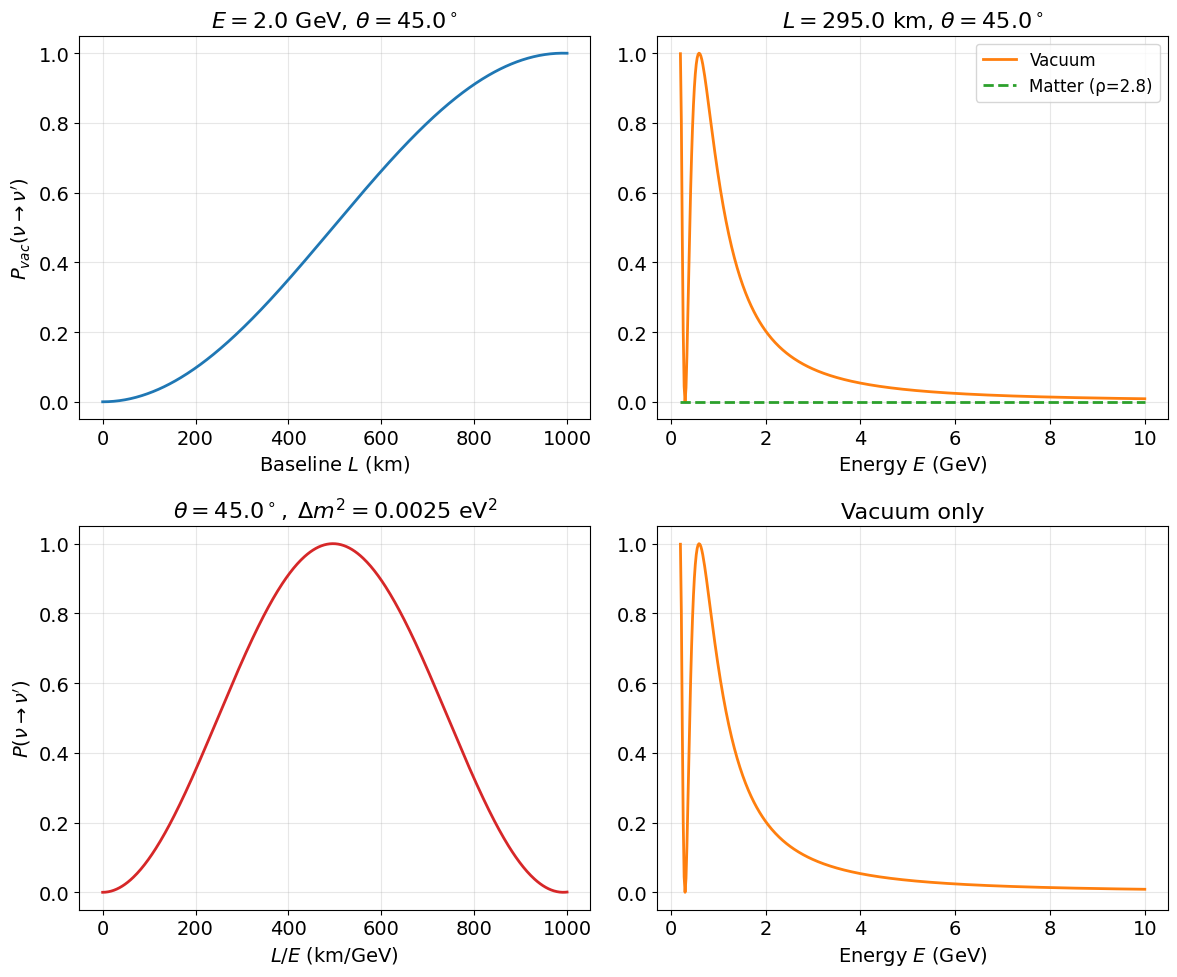

In [24]:
# ------------------------------------------------
# 1) Two‑flavor vacuum probability function
# ------------------------------------------------
def P_vac_2fl(Delta_m2, theta, L, E):
    """
    Two‑flavor vacuum oscillation:
      P = sin^2(2θ) * sin^2(1.27 * Δm2 [eV^2] * L [km] / E [GeV])
    """
    arg = 1.267 * Delta_m2 * L / E
    return np.sin(2*theta)**2 * np.sin(arg)**2

# ------------------------------------------------
# 2) Matter‑modified mixing (constant density)
# ------------------------------------------------
def P_mat_2fl(Delta_m2, theta, L, E, rho, Ye=0.5):
    """
    Two‑flavor in matter (νe<->νx), with constant density ρ [g/cm^3],
    electron fraction Ye (≈0.5 in Earth). Only valid for νe survival or
    νμ->νe appearance with CC potential.
    """
    # matter potential A = 2√2 G_F N_e E  → in same units as Δm2/E
    GF = 1.1663787e-5   # GeV⁻²
    Na = 6.022e23       # /mol
    mev2_geV2 = 1e-18   # convert eV^2->GeV^2
    # N_e (per cm^3) ≈ ρ (g/cm3) * Na (per mol) * Ye / (m_proton ~1 g/mol)
    Ve = np.sqrt(2)*GF*(rho*Na*Ye)  # in GeV
    # convert Δm2 to GeV^2
    dm2G = Delta_m2 * mev2_geV2
    # effective Δm2 and θ in matter:
    cos2t = np.cos(2*theta)
    sin2t = np.sin(2*theta)
    denom = np.sqrt((dm2G*cos2t - 2*E*Ve)**2 + (dm2G*sin2t)**2)
    dm2m = denom
    th_m = 0.5 * np.arctan2(dm2G*sin2t, dm2G*cos2t - 2*E*Ve)
    # now oscillate with Δm2m/(2E) over L:
    argm = dm2m * L * 5.07e+6 / (2*E*1.0e9)  # convert L[km]→eV⁻¹ etc.
    return np.sin(2*th_m)**2 * np.sin(argm)**2

# ------------------------------------------------
# 3) set up parameters
# ------------------------------------------------
Delta_m2 = 2.5e-3      # eV^2
theta_deg = 45.0       # degrees
theta = np.radians(theta_deg)
rho = 2.8              # g/cm^3

# ranges
L_vals = np.linspace(0, 1000, 500)        # km
E_fixed = 2.0                             # GeV

E_vals = np.linspace(0.2, 10.0, 500)      # GeV
L_fixed = 295.0                           # km

LE_vals = np.linspace(0, 1000, 500)       # km/GeV

# ------------------------------------------------
# 4) compute all curves
# ------------------------------------------------
P_L = P_vac_2fl(Delta_m2, theta, L_vals, E_fixed)
P_E = P_vac_2fl(Delta_m2, theta, L_fixed, E_vals)
P_LE= P_vac_2fl(Delta_m2, theta, LE_vals, 1.0)  # sin²(1.27 dm² * (L/E))
P_mat= P_mat_2fl(Delta_m2, theta, L_fixed, E_vals, rho)

# ------------------------------------------------
# 5) plot
# ------------------------------------------------
plt.figure(figsize=(12,10))

# 5.1 P vs L
ax = plt.subplot(2,2,1)
ax.plot(L_vals, P_L, color='C0', lw=2)
ax.set_xlabel("Baseline $L$ (km)", fontsize=14)
ax.set_ylabel(r"$P_{vac}(\nu\to\nu')$", fontsize=14)
ax.set_title(f"$E={E_fixed}$ GeV, $\\theta={theta_deg}^\\circ$", fontsize=16)
ax.grid(alpha=0.3)

# 5.2 P vs E
ax = plt.subplot(2,2,2)
ax.plot(E_vals, P_E, color='C1', lw=2, label='Vacuum')
ax.plot(E_vals, P_mat, '--', color='C2', lw=2, label='Matter (ρ=2.8)')
ax.set_xlabel("Energy $E$ (GeV)", fontsize=14)
ax.set_title(f"$L={L_fixed}$ km, $\\theta={theta_deg}^\\circ$", fontsize=16)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

# 5.3 P vs L/E
ax = plt.subplot(2,2,3)
ax.plot(LE_vals, P_LE, color='C3', lw=2)
ax.set_xlabel("$L/E$ (km/GeV)", fontsize=14)
ax.set_ylabel(r"$P(\nu\to\nu')$", fontsize=14)
ax.set_title(f"$\\theta={theta_deg}^\\circ,\;Δm^2={Delta_m2}$ eV$^2$", fontsize=16)
ax.grid(alpha=0.3)

# 5.4 Zoom of P vs E (vacuum only)
ax = plt.subplot(2,2,4)
ax.plot(E_vals, P_E, color='C1', lw=2)
ax.set_xlabel("Energy $E$ (GeV)", fontsize=14)
ax.set_title("Vacuum only", fontsize=16)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


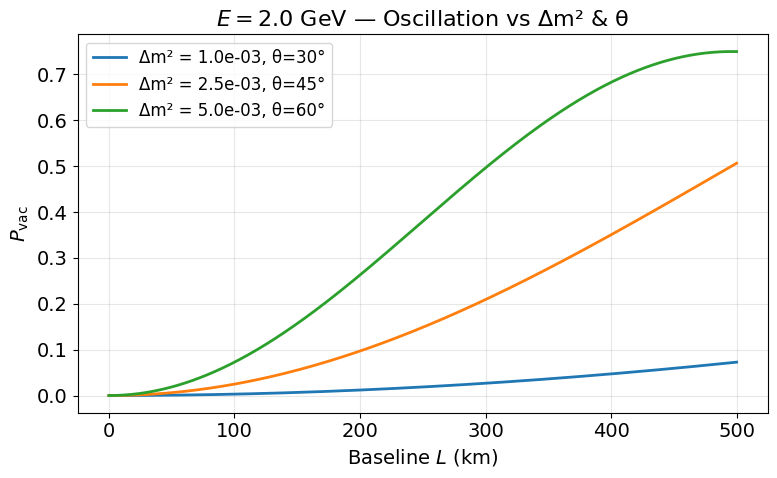

In [25]:
def P_vac_2fl(Delta_m2, theta, L, E):
    arg = 1.267 * Delta_m2 * L / E
    return np.sin(2*theta)**2 * np.sin(arg)**2

E = 2.0  # GeV
Ls = np.linspace(0, 500, 500)
dms = [1e-3, 2.5e-3, 5e-3]  # eV^2
thetas = [np.radians(30), np.radians(45), np.radians(60)]

plt.figure(figsize=(8,5))
for dm, th in zip(dms, thetas):
    plt.plot(Ls, P_vac_2fl(dm, th, Ls, E), lw=2,
             label=f"Δm² = {dm:.1e}, θ={np.degrees(th):.0f}°")
plt.xlabel("Baseline $L$ (km)", fontsize=14)
plt.ylabel(r"$P_{\rm vac}$", fontsize=14)
plt.title(f"$E={E}$ GeV — Oscillation vs Δm² & θ", fontsize=16)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


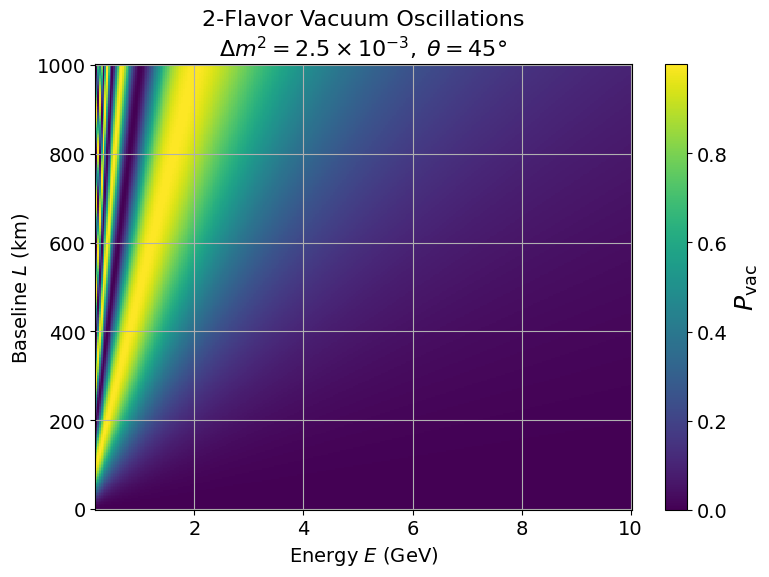

In [26]:
E_vals = np.linspace(0.2, 10, 300)
L_vals = np.linspace(0, 1000, 300)
Delta_m2 = 2.5e-3
theta = np.radians(45)

P2D = np.empty((len(L_vals), len(E_vals)))
for i,L in enumerate(L_vals):
    P2D[i,:] = P_vac_2fl(Delta_m2, theta, L, E_vals)

plt.figure(figsize=(8,6))
im = plt.pcolormesh(E_vals, L_vals, P2D, shading='auto', cmap='viridis')
plt.colorbar(im, label=r"$P_{\rm vac}$")
plt.xlabel("Energy $E$ (GeV)", fontsize=14)
plt.ylabel("Baseline $L$ (km)", fontsize=14)
plt.title("2‑Flavor Vacuum Oscillations\n$\\Delta m^2=2.5\\times10^{-3},\\;\\theta=45°$", fontsize=16)
plt.tight_layout()
plt.show()


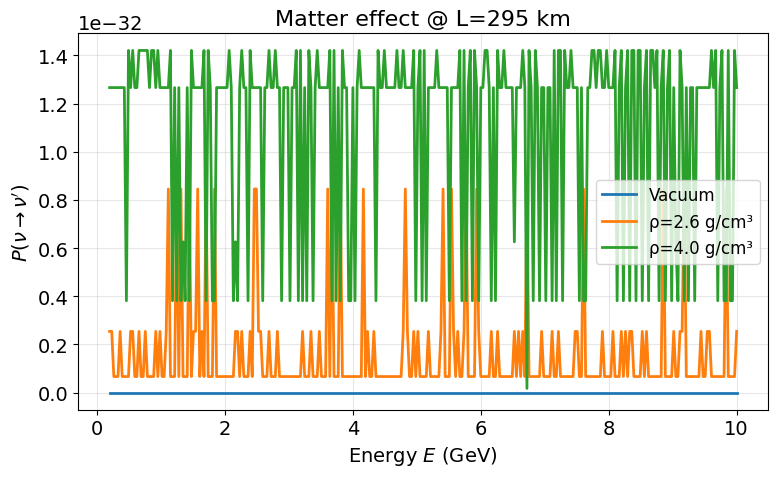

In [27]:
from matplotlib.lines import Line2D

E = np.linspace(0.2, 10, 300)
L = 295  # km
Delta_m2 = 2.5e-3
theta = np.radians(45)
rhos = [0.0, 2.6, 4.0]  # g/cm^3: vacuum→crust→mantle

def P_mat(Delta_m2, theta, L, E, rho):
    # simple two‑flavor matter effect (as above)
    GF=1.166e-5; Na=6.022e23; Ye=0.5
    Ve=np.sqrt(2)*GF*(rho*Na*Ye)
    dm2G=Delta_m2*1e-18
    c2, s2 = np.cos(2*theta), np.sin(2*theta)
    denom = np.sqrt((dm2G*c2 - 2*E*Ve)**2 + (dm2G*s2)**2)
    thm = 0.5*np.arctan2(dm2G*s2, dm2G*c2 - 2*E*Ve)
    arg = denom * L * 5.07e6 / (2*E*1e9)
    return np.sin(2*thm)**2 * np.sin(arg)**2

plt.figure(figsize=(8,5))
for rho in rhos:
    label = "Vacuum" if rho==0 else f"ρ={rho} g/cm³"
    P = P_mat(Delta_m2, theta, L, E, rho)
    plt.plot(E, P, lw=2, label=label)

plt.xlabel("Energy $E$ (GeV)", fontsize=14)
plt.ylabel(r"$P(\nu\to\nu')$", fontsize=14)
plt.title(f"Matter effect @ L={L} km", fontsize=16)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [28]:
import pandas as pd

# ─── Table 1: Oscillation Parameters & Constants ───
params = [
    {"Parameter": "θ₁₂",         "Value": 33.9,       "Units": "°",     "Notes": "Solar mixing angle"},
    {"Parameter": "θ₁₃",         "Value": 9.1,        "Units": "°",     "Notes": "Reactor mixing angle"},
    {"Parameter": "θ₂₃",         "Value": 49.6,       "Units": "°",     "Notes": "Atmospheric mixing angle"},
    {"Parameter": "Δm²₂₁",       "Value": 7.42e-5,    "Units": "eV²",   "Notes": "Solar mass² splitting"},
    {"Parameter": "Δm²₃₁",       "Value": 2.51e-3,    "Units": "eV²",   "Notes": "Atmospheric mass² splitting"},
    {"Parameter": "Baseline L",  "Value": 810,        "Units": "km",    "Notes": "NOvA far detector"},
    {"Parameter": "E grid",      "Value": "0.5–5.0",  "Units": "GeV",   "Notes": "Energy sampling range"},
    {"Parameter": "⍴",           "Value": 2.8,        "Units": "g/cm³", "Notes": "Earth’s crust density"},
    {"Parameter": "G_F",         "Value": 1.166e-5,   "Units": "GeV⁻²", "Notes": "Fermi constant"},
]
df_params = pd.DataFrame(params)


# ─── Table 2: Grid Choices for Foundational 2‑Flavour Plots ───
grids = [
    {"Plot": "Survival vs E",           "X axis": "E (GeV)",       "Y axis": "P(ν→ν)",      "Grid pts.": "200",    "Notes": "E from 0.1 to 10 GeV"},
    {"Plot": "Survival vs L/E",         "X axis": "L/E (km/GeV)",   "Y axis": "P(ν→ν)",      "Grid pts.": "200",    "Notes": "L/E 100–1000 km/GeV"},
    {"Plot": "Contour in θ–Δm² space",  "X axis": "θ (°)",          "Y axis": "Δm² (eV²)",   "Grid pts.": "50×50",  "Notes": "θ 0–90°, Δm² 10⁻⁴–10⁻²"},
    {"Plot": "Phase vs Baseline",       "X axis": "L (km)",         "Y axis": "φ (rad)",      "Grid pts.": "300",    "Notes": "φ=1.27Δm²L/E at fixed E"},
]
df_grids = pd.DataFrame(grids)


# Display them
print("\nOscillation Parameters & Constants:\n")
print(df_params.to_string(index=False))

print("\nGrid Choices for Foundational Plots:\n")
print(df_grids.to_string(index=False))



Oscillation Parameters & Constants:

 Parameter     Value Units                       Notes
       θ₁₂      33.9     °          Solar mixing angle
       θ₁₃       9.1     °        Reactor mixing angle
       θ₂₃      49.6     °    Atmospheric mixing angle
     Δm²₂₁  0.000074   eV²       Solar mass² splitting
     Δm²₃₁   0.00251   eV² Atmospheric mass² splitting
Baseline L       810    km           NOvA far detector
    E grid   0.5–5.0   GeV       Energy sampling range
         ⍴       2.8 g/cm³       Earth’s crust density
       G_F  0.000012 GeV⁻²              Fermi constant

Grid Choices for Foundational Plots:

                  Plot       X axis    Y axis Grid pts.                   Notes
         Survival vs E      E (GeV)    P(ν→ν)       200    E from 0.1 to 10 GeV
       Survival vs L/E L/E (km/GeV)    P(ν→ν)       200     L/E 100–1000 km/GeV
Contour in θ–Δm² space        θ (°) Δm² (eV²)     50×50  θ 0–90°, Δm² 10⁻⁴–10⁻²
     Phase vs Baseline       L (km)   φ (rad)       3

In [29]:
def two_flav_survival(E, L, dm2, theta):
    """
    Two-flavour ν_α → ν_α survival probability.
    E     : neutrino energy in GeV
    L     : baseline in km
    dm2   : Δm² in eV²
    theta : mixing angle in radians
    """
    # oscillation phase: 1.267 turns (eV²·km)/(GeV)
    phi = 1.267 * dm2 * L / E
    return 1 - (np.sin(2*theta)**2) * (np.sin(phi)**2)

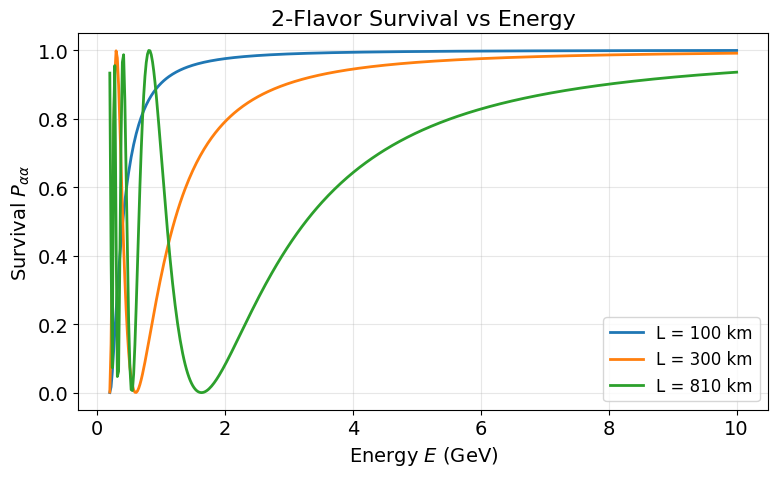

In [30]:
# Parameters
dm2   = 2.5e-3     # eV²
theta = np.radians(45)  # maximal mixing

E = np.linspace(0.2, 10, 500)  # GeV
Ls = [100, 300, 810]           # km

plt.figure(figsize=(8,5))
for L in Ls:
    P = two_flav_survival(E, L, dm2, theta)
    plt.plot(E, P, label=f"L = {L} km")

plt.xlabel("Energy $E$ (GeV)",     fontsize=14)
plt.ylabel("Survival $P_{\\alpha\\alpha}$", fontsize=14)
plt.title("2-Flavor Survival vs Energy", fontsize=16)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


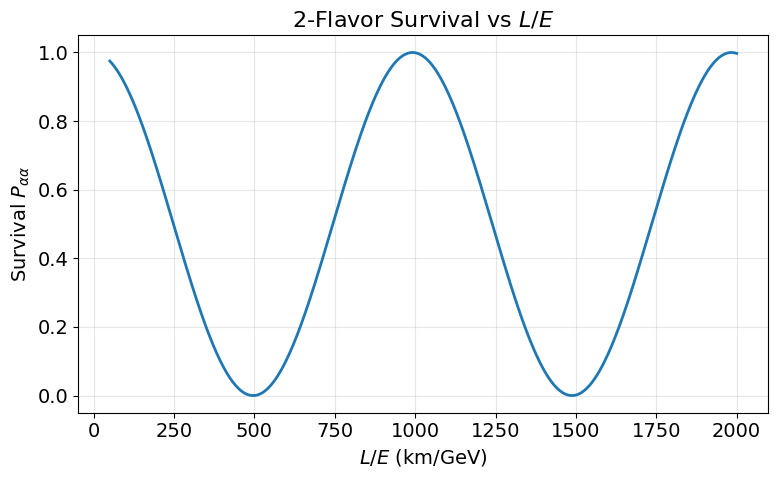

In [31]:
LE = np.linspace(50, 2000, 500)  # km/GeV

plt.figure(figsize=(8,5))
P = two_flav_survival(1.0, LE, dm2, theta)  # interpret E=1 so φ∼dm2×LE
# actually phi = 1.267 dm2 L/E ⇒ we can scale accordingly:
phi = 1.267 * dm2 * LE
P = 1 - np.sin(2*theta)**2 * np.sin(phi)**2

plt.plot(LE, P, color='tab:blue')
plt.xlabel("$L/E$ (km/GeV)",       fontsize=14)
plt.ylabel("Survival $P_{\\alpha\\alpha}$", fontsize=14)
plt.title("2-Flavor Survival vs $L/E$", fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

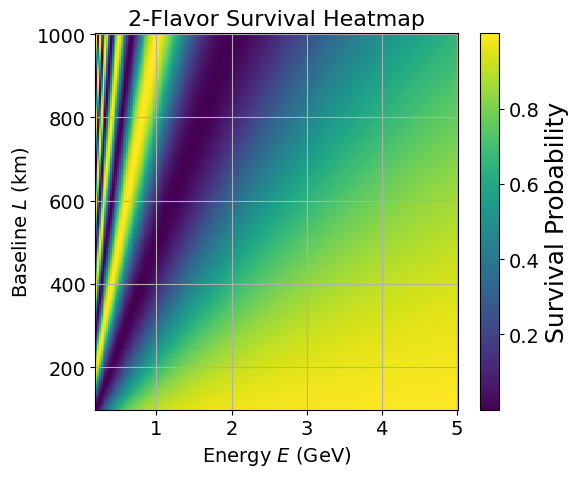

In [32]:
E_grid = np.linspace(0.2, 5, 200)
L_grid = np.linspace(100, 1000, 200)
EE, LL = np.meshgrid(E_grid, L_grid)
Phi = 1.267 * dm2 * LL / EE
PP   = 1 - np.sin(2*theta)**2 * np.sin(Phi)**2

plt.figure(figsize=(6,5))
cs = plt.pcolormesh(EE, LL, PP, cmap="viridis", shading="auto")
plt.colorbar(cs, label="Survival Probability")
plt.xlabel("Energy $E$ (GeV)", fontsize=14)
plt.ylabel("Baseline $L$ (km)",     fontsize=14)
plt.title("2-Flavor Survival Heatmap", fontsize=16)
plt.tight_layout()
plt.show()


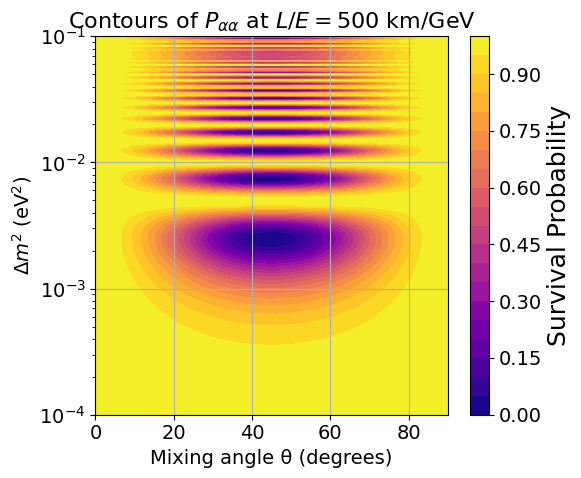

In [33]:
# fix L/E so that phi = 1.267 * dm2 * (L/E)
LE0 = 500  # km/GeV
th = np.linspace(0, np.pi/2, 200)
dm = np.logspace(-4, -1, 200)
TH, DM = np.meshgrid(th, dm)
PHI = 1.267 * DM * LE0
PP  = 1 - np.sin(2*TH)**2 * np.sin(PHI)**2

plt.figure(figsize=(6,5))
cont = plt.contourf(np.degrees(TH), DM, PP, levels=20, cmap="plasma")
plt.colorbar(cont, label="Survival Probability")
plt.xlabel("Mixing angle θ (degrees)", fontsize=14)
plt.ylabel(r"$\Delta m^2$ (eV$^2$)",     fontsize=14)
plt.xlim(0,90)
plt.yscale("log")
plt.title(r"Contours of $P_{\alpha\alpha}$ at $L/E=500$ km/GeV", fontsize=16)
plt.tight_layout()
plt.show()
